In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import glob
import os
import warnings

# Paramètres de style pour des graphiques esthétiques et professionnels
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# Analyse Détaillée des Risques Mondiaux (World Risk Index)

L'objectif de cette analyse est de visualiser et d'explorer la base de données du **World Risk Index**, qui évalue les risques de catastrophes naturelles en croisant deux composantes essentielles :
1. **L'Exposition (E)** : la probabilité physique d'être touché par une catastrophe.
2. **La Vulnérabilité (V)** : la propension d'une société à subir des dommages, définie par la **Susceptibilité (S)**, le **Manque de capacités de réponse (C)** et le **Manque de capacités d'adaptation (A)**.

Nous chercherons à mettre en évidence **le lien direct entre la situation socio-économique d'un pays et son risque face aux catastrophes**.

In [2]:
# 1. Chargement et Agrégation des Données
all_files = glob.glob('Dataset/year_data/*.csv')
df_list = []

import re

for f in all_files:
    temp_df = pd.read_csv(f)
    # Extract year from filename (e.g., worldriskindex-2000.csv -> 2000)
    year_match = re.search(r'(\d{4})', f)
    if year_match:
        temp_df['Year'] = int(year_match.group(1))
    
    # Standardize column names
    if 'Country' in temp_df.columns:
        temp_df.rename(columns={'Country': 'WRI.Country'}, inplace=True)
    if 'ISO3' in temp_df.columns:
        temp_df.rename(columns={'ISO3': 'ISO3.Code'}, inplace=True)
        
    df_list.append(temp_df)

df = pd.concat(df_list, axis=0, ignore_index=True)

# S'assurer que les valeurs numériques sont correctement formatées si besoin
cols_numeriques = ['W', 'E', 'V', 'S', 'C', 'A']
for c in cols_numeriques:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Récupération de l'année la plus récente pour l'analyse spatiale (ex: 2025)
latest_year = df['Year'].max()
df_latest = df[df['Year'] == latest_year].dropna(subset=['W', 'E', 'V'])

print(f"Dataset consolidé. Nombre de lignes: {len(df)}. Année récente utilisée pour la cartographie : {latest_year}")

Dataset consolidé. Nombre de lignes: 5018. Année récente utilisée pour la cartographie : 2025


## 1. Cartographie Mondiale et Distribution Spatiale
Une vision globale permet immédiatement d'identifier les zones géographiques les plus exposées et les plus vulnérables.

In [3]:
# Graphique 1 : Carte Mondiale du WorldRiskIndex (W)
fig1 = px.choropleth(
    df_latest, 
    locations="ISO3.Code", 
    color="W", 
    hover_name="WRI.Country", 
    color_continuous_scale="Reds",
    title=f"🌐 Global WorldRiskIndex ({latest_year})",
    labels={'W': 'WorldRiskIndex'}
)
fig1.update_layout(geo=dict(showcoastlines=True), margin={"r":0,"t":40,"l":0,"b":0})
fig1.show()

In [4]:
# Graphique 2 : Carte Mondiale de la Vulnérabilité Socio-Économique (V)
fig2 = px.choropleth(
    df_latest, 
    locations="ISO3.Code", 
    color="V", 
    hover_name="WRI.Country", 
    color_continuous_scale="Purples",
    title=f"🛡️ Global Vulnerability ({latest_year})",
    labels={'V': 'Vulnerability'}
)
fig2.update_layout(geo=dict(showcoastlines=True), margin={"r":0,"t":40,"l":0,"b":0})
fig2.show()

In [5]:
# Graphique 3 : Carte Mondiale de l'Exposition aux Aléas (E)
fig3 = px.choropleth(
    df_latest, 
    locations="ISO3.Code", 
    color="E", 
    hover_name="WRI.Country", 
    color_continuous_scale="Oranges",
    title=f"⚡ Global Exposition ({latest_year})",
    labels={'E': 'Exposition'}
)
fig3.update_layout(geo=dict(showcoastlines=True), margin={"r":0,"t":40,"l":0,"b":0})
fig3.show()

## 2. Les Pays les Plus à Risque : Palmarès et Hiérarchies
Identifions les pays qui dominent malheureusement ces classements.

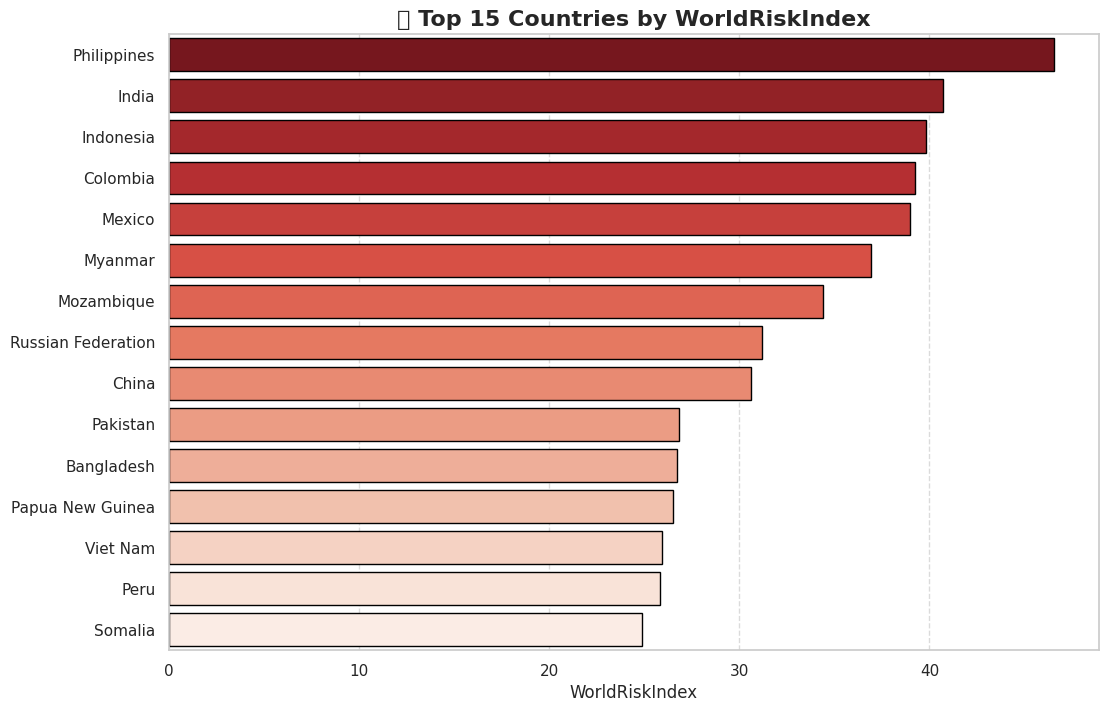

In [6]:
# Graphique 4 : Top 15 des pays avec le risque global le plus élevé
top_15_risk = df_latest.nlargest(15, 'W')

plt.figure(figsize=(12, 8))
sns.barplot(data=top_15_risk, x='W', y='WRI.Country', palette='Reds_r', edgecolor="black")
plt.title('🔴 Top 15 Countries by WorldRiskIndex', fontsize=16, fontweight='bold')
plt.xlabel('WorldRiskIndex')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

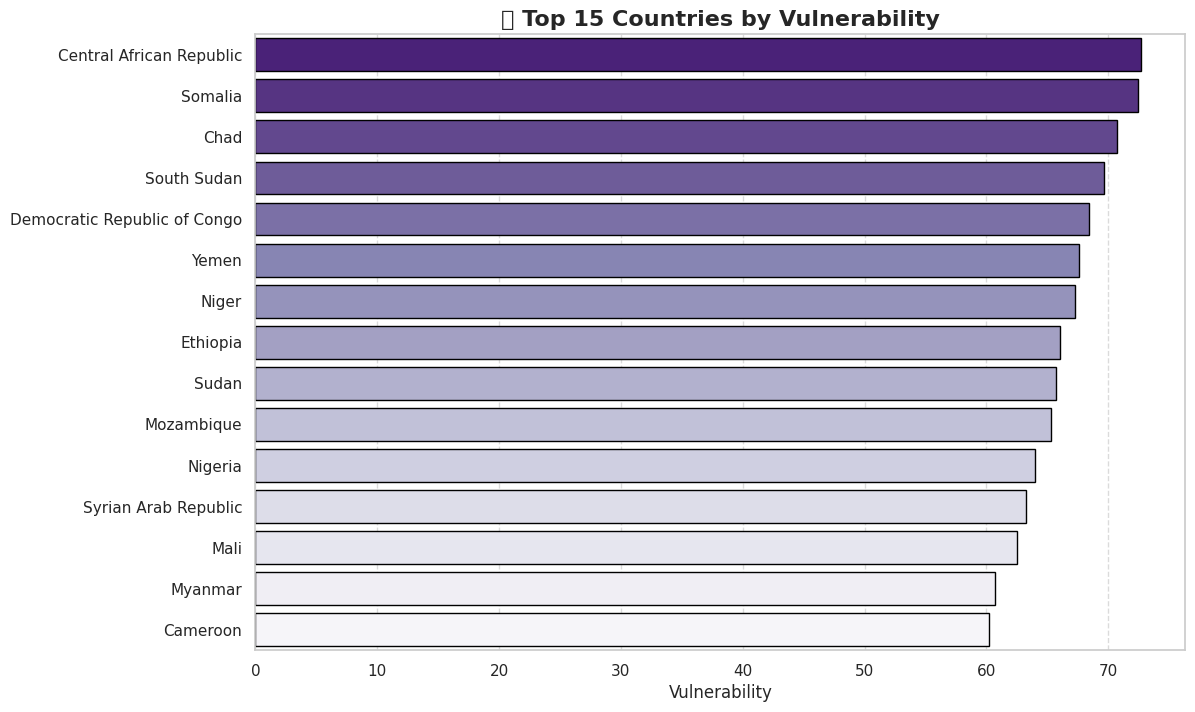

In [7]:
# Graphique 5 : Top 15 des pays les plus Vulnérables (Facteur socio-économique)
top_15_vuln = df_latest.nlargest(15, 'V')

plt.figure(figsize=(12, 8))
sns.barplot(data=top_15_vuln, x='V', y='WRI.Country', palette='Purples_r', edgecolor="black")
plt.title('🟣 Top 15 Countries by Vulnerability', fontsize=16, fontweight='bold')
plt.xlabel('Vulnerability')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 3. Croisement : Exposition vs Vulnérabilité (Le Coeur du Risque)
Comment une forte exposition couplée à une très mauvaise situation socio-économique engendre-t-elle un désastre potentiel ?

In [8]:
# Graphique 6 : Nuage de points interactif (Exposition vs Vulnérabilité)
fig4 = px.scatter(
    df_latest, x='E', y='V', size='W', color='W', hover_name='WRI.Country',
    color_continuous_scale='Turbo', size_max=40,
    title='🎯 Exposition vs Vulnerability',
    labels={'E': 'Exposition', 'V': 'Vulnerability', 'W': 'WorldRiskIndex'}
)
fig4.add_vline(x=df_latest['E'].median(), line_dash="dash", line_color="gray", annotation_text="Average Exposition")
fig4.add_hline(y=df_latest['V'].median(), line_dash="dash", line_color="gray", annotation_text="Average Vulnerability")
fig4.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))
fig4.show()

## 5. Distributions Internes : Les Maux de L'Humanité
Comparons la répartition globale des scores de faiblesses sociales et économiques.

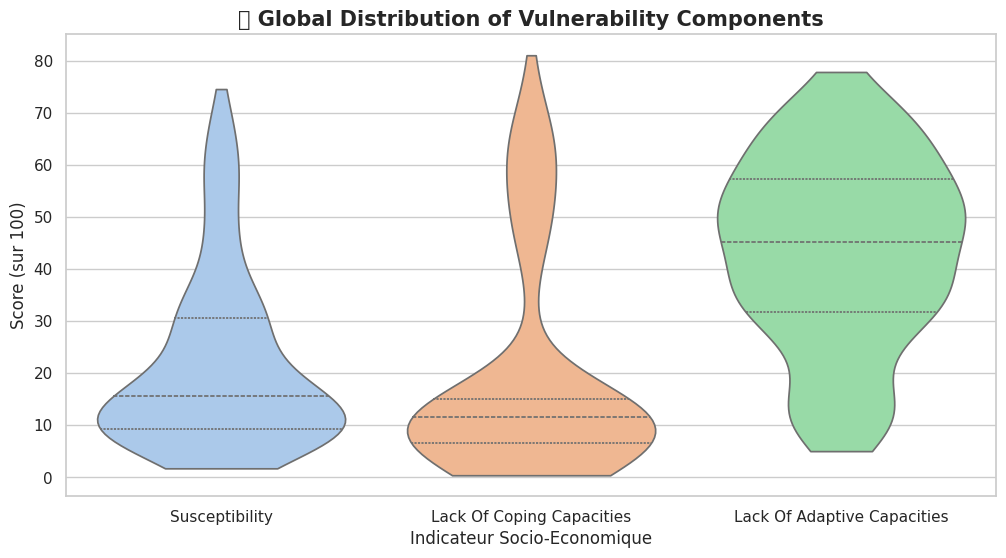

In [9]:
# Graphique 11 : Violons des Composantes Structurantes (S, C, A)
df_melted_vuln = df_latest.melt(
    id_vars=['WRI.Country'], 
    value_vars=['S', 'C', 'A'], 
    var_name='Indicateur Socio-Economique', 
    value_name='Score'
)

plt.figure(figsize=(12, 6))
sns.violinplot(
    x='Indicateur Socio-Economique', y='Score', data=df_melted_vuln, 
    palette='pastel', inner="quart", cut=0
)
plt.title('🎻 Global Distribution of Vulnerability Components', fontsize=15, fontweight='bold')
plt.xticks(ticks=[0, 1, 2], labels=['Susceptibility', 'Lack Of Coping Capacities', 'Lack Of Adaptive Capacities'])
plt.ylabel('Score (sur 100)')
plt.show()

In [ ]:
# Graphique 14 : Évolution de la Vulnérabilité (Socio-Économique) pour le TOP 5 Pays à haut risque actuels
import matplotlib.ticker as ticker

top_5_countries = top_15_risk.head(5)['WRI.Country'].tolist()
df_top_5 = df[df['WRI.Country'].isin(top_5_countries)].sort_values(by='Year')

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_top_5, x='Year', y='V', hue='WRI.Country', marker='D', linewidth=2)
plt.title('🛡️ Vulnerability Trend For Top 5 At-Risk Countries', fontsize=15, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Vulnerability')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(sorted(df['Year'].dropna().unique()), rotation=45)
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

## 9. Top Gagnants et Perdants du 21e Siècle (Décalage de Vulnérabilité)
Lesquels ont le plus amélioré leur capacité de réponse entre l'année 2000 et l'année 2025 (preuve d'évolution socio-économique) ?

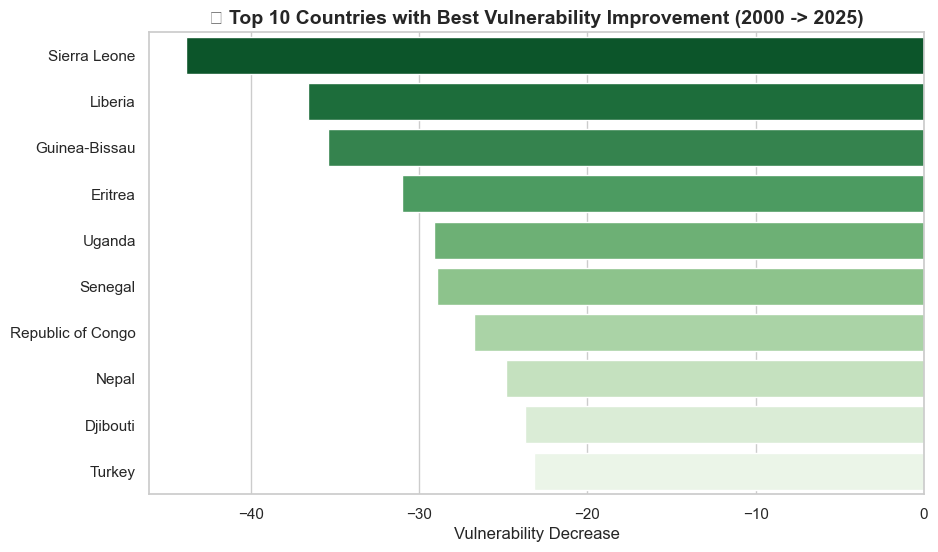

In [ ]:
# Préparation des données d'évolution E, V et W
min_year = df['Year'].min()
max_year = df['Year'].max()

df_start = df[df['Year'] == min_year][['WRI.Country', 'W', 'V', 'C', 'ISO3.Code']].set_index('WRI.Country')
df_end = df[df['Year'] == max_year][['WRI.Country', 'W', 'V', 'C']].set_index('WRI.Country')

# Fusionner en calculant la différence Différence = Fin - Début 
diff_df = df_end.join(df_start, lsuffix='_End', rsuffix='_Start').dropna()
diff_df['Diff_V'] = diff_df['V_End'] - diff_df['V_Start']
diff_df['Diff_W'] = diff_df['W_End'] - diff_df['W_Start']

diff_df = diff_df.reset_index()

# 1. Les 10 qui ont le plus baissé leur vulnérabilité (Amélioration !)
top_improvers = diff_df.sort_values(by='Diff_V', ascending=True).head(10)
# 2. Les 10 dont la vulnérabilité a le plus augmenté (Dégradation)
top_degraders = diff_df.sort_values(by='Diff_V', ascending=False).head(10)

# Graphique 17 : Top Améliorations de Vulnérabilité
plt.figure(figsize=(10, 6))
sns.barplot(data=top_improvers, x='Diff_V', y='WRI.Country', palette='Greens_r')
plt.title(f'🟢 Top 10 Countries with Best Vulnerability Improvement ({min_year} -> {max_year})', fontsize=14, fontweight='bold')
plt.xlabel('Vulnerability Decrease')
plt.ylabel('')
plt.show()

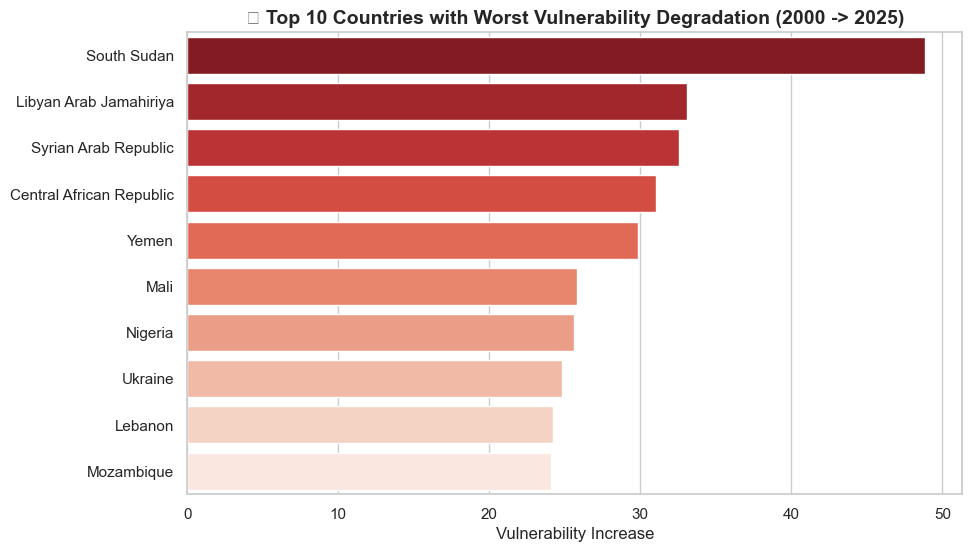

In [ ]:
# Graphique 18 : Dégradations Sensibles
plt.figure(figsize=(10, 6))
sns.barplot(data=top_degraders, x='Diff_V', y='WRI.Country', palette='Reds_r')
plt.title(f'🔴 Top 10 Countries with Worst Vulnerability Degradation ({min_year} -> {max_year})', fontsize=14, fontweight='bold')
plt.xlabel('Vulnerability Increase')
plt.ylabel('')
plt.show()

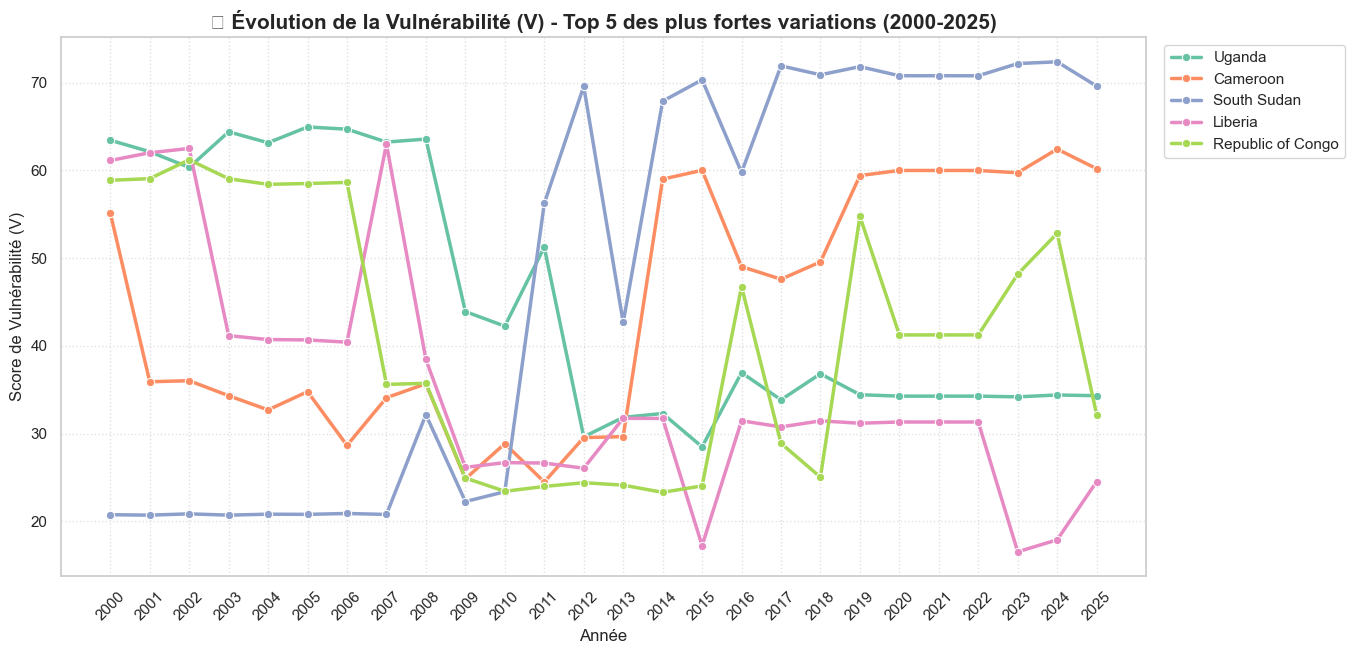

In [ ]:
# Graphique 19 : Top 5 des pays avec la plus grande variation de Vulnérabilité (V) sur 26 ans
# Calcul de la variance (ou écart-type) pour chaque pays
vuln_variance = df.groupby('WRI.Country')['V'].std().sort_values(ascending=False)
top_5_var_v = vuln_variance.head(5).index.tolist()

df_var_v = df[df['WRI.Country'].isin(top_5_var_v)].sort_values(by='Year')

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_var_v, x='Year', y='V', hue='WRI.Country', marker='o', linewidth=2.5)
plt.title('📈 Évolution de la Vulnérabilité (V) - Top 5 des plus fortes variations (2000-2025)', fontsize=15, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Score de Vulnérabilité (V)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(sorted(df['Year'].dropna().unique()), rotation=45)
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

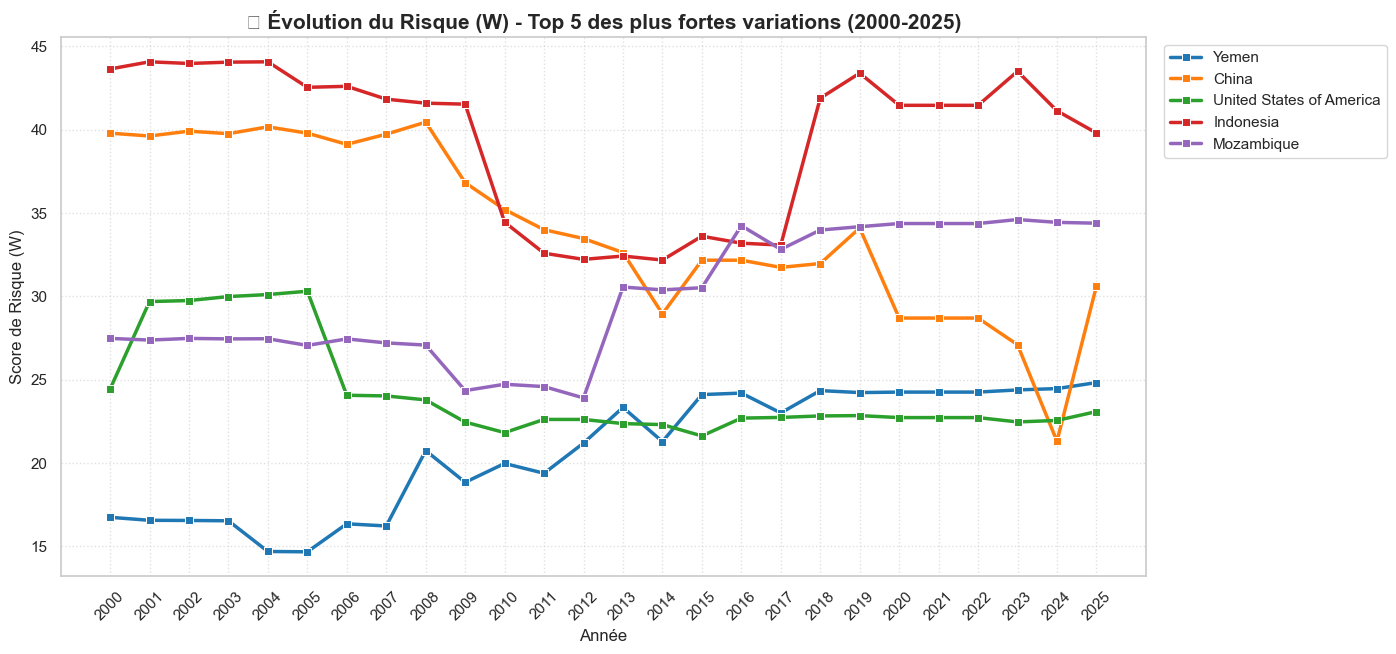

In [ ]:
# Graphique 20 : Top 5 des pays avec la plus grande variation de Risque (W) sur 26 ans
# Calcul de la variance (ou écart-type) pour chaque pays
risk_variance = df.groupby('WRI.Country')['W'].std().sort_values(ascending=False)
top_5_var_w = risk_variance.head(5).index.tolist()

df_var_w = df[df['WRI.Country'].isin(top_5_var_w)].sort_values(by='Year')

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_var_w, x='Year', y='W', hue='WRI.Country', marker='s', linewidth=2.5, palette='tab10')
plt.title('📈 Évolution du Risque (W) - Top 5 des plus fortes variations (2000-2025)', fontsize=15, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Score de Risque (W)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(sorted(df['Year'].dropna().unique()), rotation=45)
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

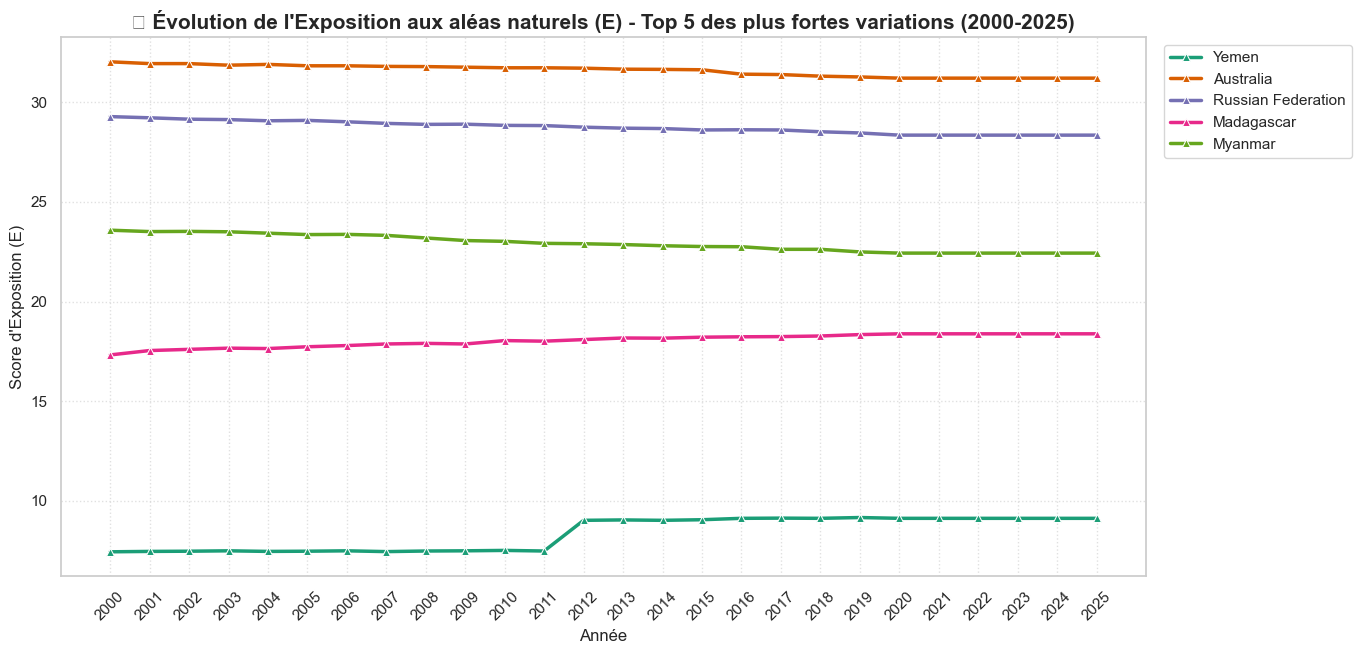

In [ ]:
# Graphique 21 : Top 5 des pays avec la plus grande variation d'Exposition (E) sur 26 ans
# L'exposition représente l'impact des aléas naturels (tremblements de terre, tsunamis, inondations, sécheresses, etc.)
exposure_variance = df.groupby('WRI.Country')['E'].std().sort_values(ascending=False)
top_5_var_e = exposure_variance.head(5).index.tolist()

df_var_e = df[df['WRI.Country'].isin(top_5_var_e)].sort_values(by='Year')

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_var_e, x='Year', y='E', hue='WRI.Country', marker='^', linewidth=2.5, palette='Dark2')
plt.title('📈 Évolution de l\'Exposition aux aléas naturels (E) - Top 5 des plus fortes variations (2000-2025)', fontsize=15, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Score d\'Exposition (E)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(sorted(df['Year'].dropna().unique()), rotation=45)
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

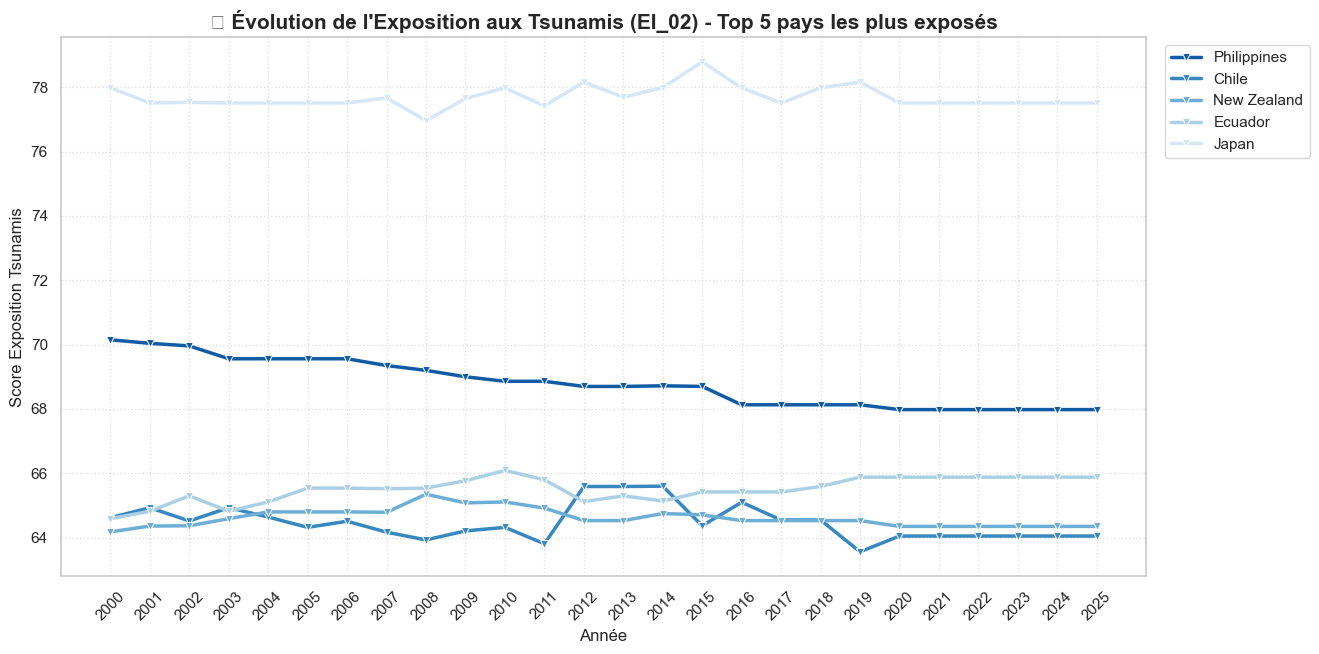

In [ ]:
# Graphique 22 : Focus sur l'évolution des Aléas Spécifiques (Tsunamis, Séismes, Cyclones...) 
# Dans la méthode WRI, les sous-indicateurs EI_01 à EI_07 concernent les aléas naturels spécifiques
# (ex: EI_01 Séismes, EI_02 Tsunamis, EI_03 Inondations Côtières, EI_04 Inondations Fluviales, EI_05 Cyclones, EI_06 Sécheresses, EI_07 Montée des eaux)

# S'assurer que ces colonnes sont numériques
ei_cols = ['EI_01', 'EI_02', 'EI_03', 'EI_04', 'EI_05', 'EI_06', 'EI_07']
for c in ei_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Exemple : Focus sur l'exposition aux Tsunamis (EI_02)
# Trouver les 5 pays avec la plus forte exposition historique moyenne aux Tsunamis
if 'EI_02' in df.columns:
    top_5_tsunami = df.groupby('WRI.Country')['EI_02'].mean().sort_values(ascending=False).head(5).index.tolist()
    df_tsunami = df[df['WRI.Country'].isin(top_5_tsunami)].sort_values(by='Year')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=df_tsunami, x='Year', y='EI_02', hue='WRI.Country', marker='v', linewidth=2.5, palette='Blues_r')
    plt.title('🌊 Évolution de l\'Exposition aux Tsunamis (EI_02) - Top 5 pays les plus exposés', fontsize=15, fontweight='bold')
    plt.xlabel('Année')
    plt.ylabel('Score Exposition Tsunamis')
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.xticks(sorted(df['Year'].dropna().unique()), rotation=45)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.show()

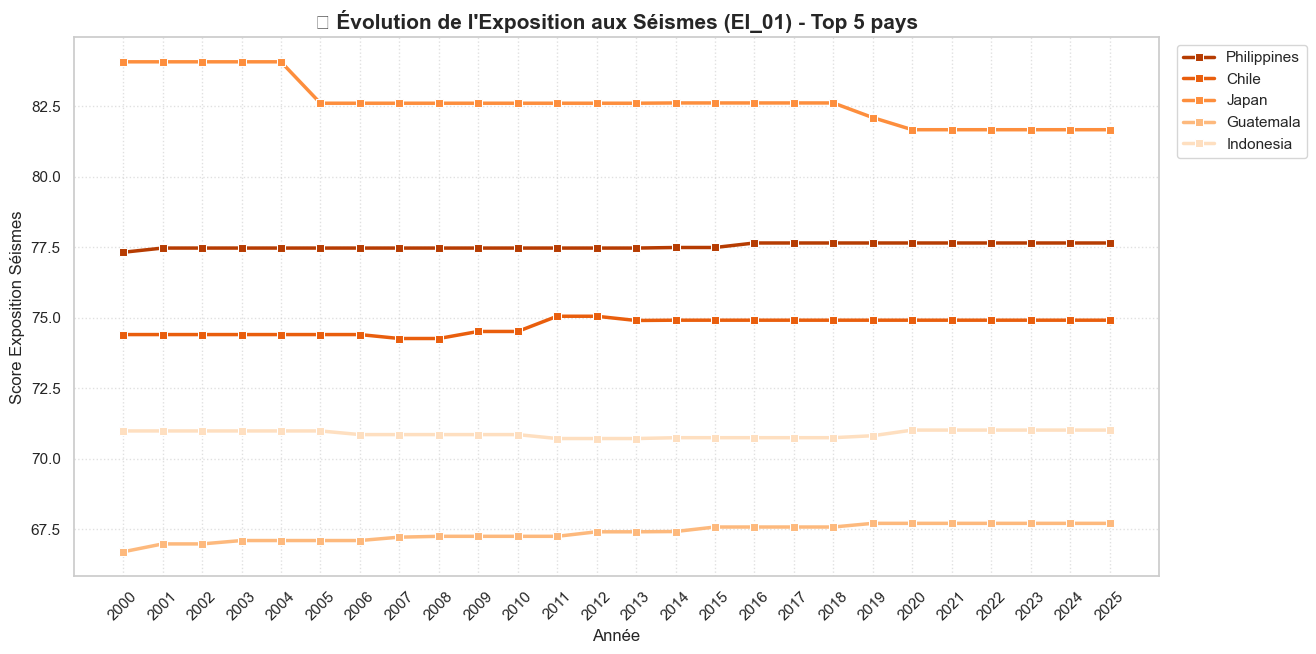

In [ ]:
# Graphique 23 : Focus sur l'évolution aux Séismes (EI_01)
if 'EI_01' in df.columns:
    top_5_seisme = df.groupby('WRI.Country')['EI_01'].mean().sort_values(ascending=False).head(5).index.tolist()
    df_seisme = df[df['WRI.Country'].isin(top_5_seisme)].sort_values(by='Year')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=df_seisme, x='Year', y='EI_01', hue='WRI.Country', marker='s', linewidth=2.5, palette='Oranges_r')
    plt.title('🌋 Évolution de l\'Exposition aux Séismes (EI_01) - Top 5 pays', fontsize=15, fontweight='bold')
    plt.xlabel('Année')
    plt.ylabel('Score Exposition Séismes')
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.xticks(sorted(df['Year'].dropna().unique()), rotation=45)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.show()

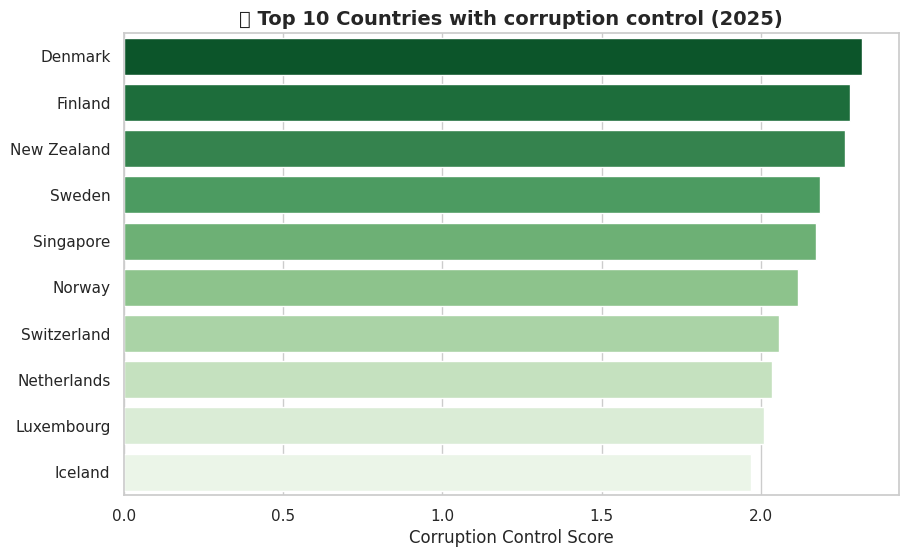

In [ ]:
df_countries_corruption = df.groupby('WRI.Country')['CI_03a_Base'].mean().reset_index()
top_ten_countries = df_countries_corruption.sort_values(by='CI_03a_Base', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_ten_countries, x='CI_03a_Base', y='WRI.Country', palette='Greens_r')
plt.title(f'🟢 Top 10 Countries with corruption control (2025)', fontsize=14, fontweight='bold')
plt.xlabel('Corruption Control Score')
plt.ylabel('')
plt.show()

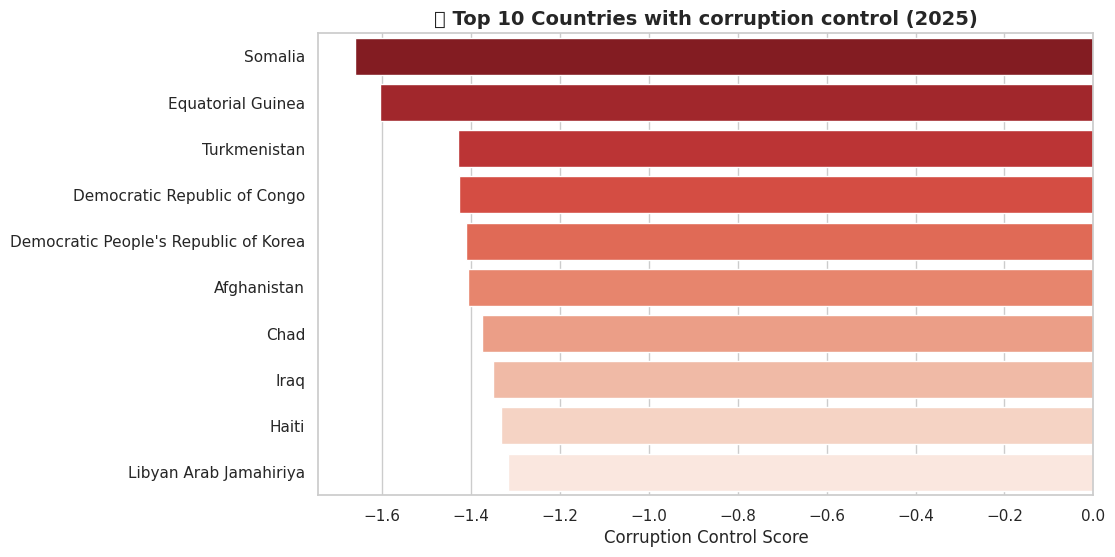

In [ ]:
top_ten_countries = df_countries_corruption.sort_values(by='CI_03a_Base', ascending=True).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_ten_countries, x='CI_03a_Base', y='WRI.Country', palette='Reds_r')
plt.title(f'🔴 Top 10 Countries with corruption control (2025)', fontsize=14, fontweight='bold')
plt.xlabel('Corruption Control Score')
plt.ylabel('')
plt.show()

<Axes: >

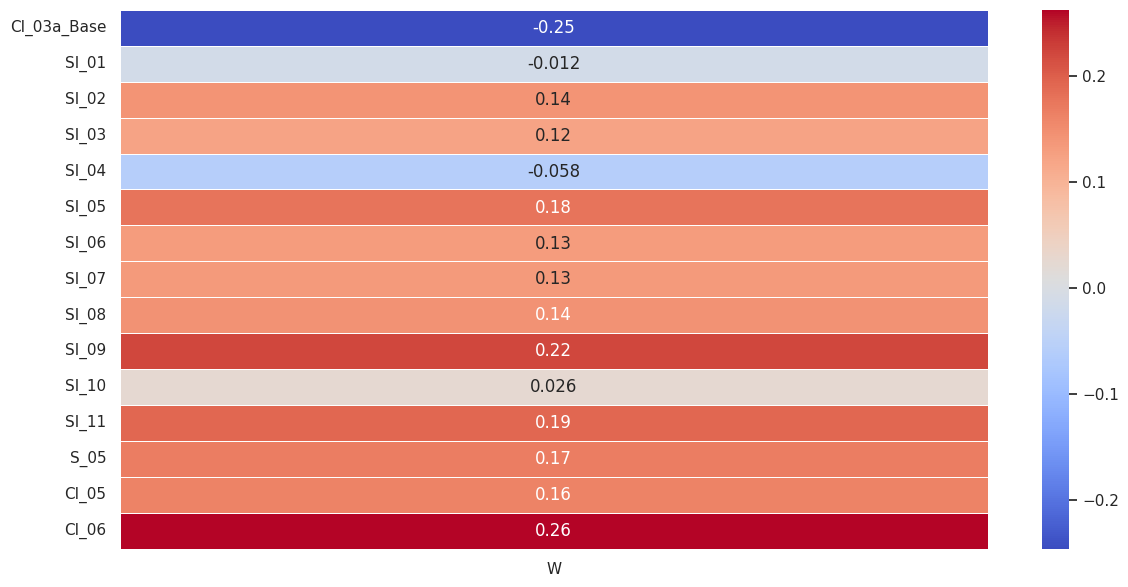

In [ ]:
columns_to_corr = ['CI_03a_Base', 'W', 'SI_01', 'SI_02', 'SI_03', 'SI_04', 'SI_05', 'SI_06', 'SI_07', 'SI_08', 'SI_09', 'SI_10', 'SI_11', 'S_05', 'CI_05', 'CI_06']
df_countries_scores_corr = df.groupby('WRI.Country')[columns_to_corr].mean().reset_index()
df_temp = df_countries_scores_corr[columns_to_corr].corr()
X = df_temp[['W']]
X.drop('W', axis=0, inplace=True)
sns.heatmap(X, annot=True, cmap='coolwarm', linewidths=0.5)

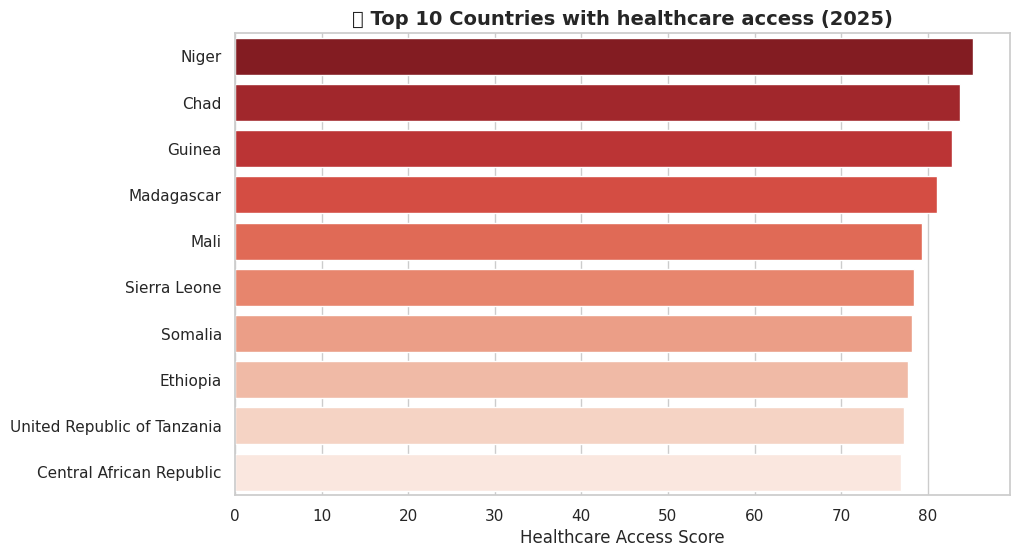

In [ ]:
df_countries_healthcare = df.groupby('WRI.Country')[['CI_05', 'CI_06']].mean().reset_index()
df_countries_healthcare["avg"] = df_countries_healthcare[['CI_05', 'CI_06']].mean(axis=1)
top_ten_countries = df_countries_healthcare.sort_values(by='avg', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_ten_countries, x='avg', y='WRI.Country', palette='Reds_r')
plt.title(f'🟢 Top 10 Countries with healthcare access (2025)', fontsize=14, fontweight='bold')
plt.xlabel('Healthcare Access Score')
plt.ylabel('')
plt.show()

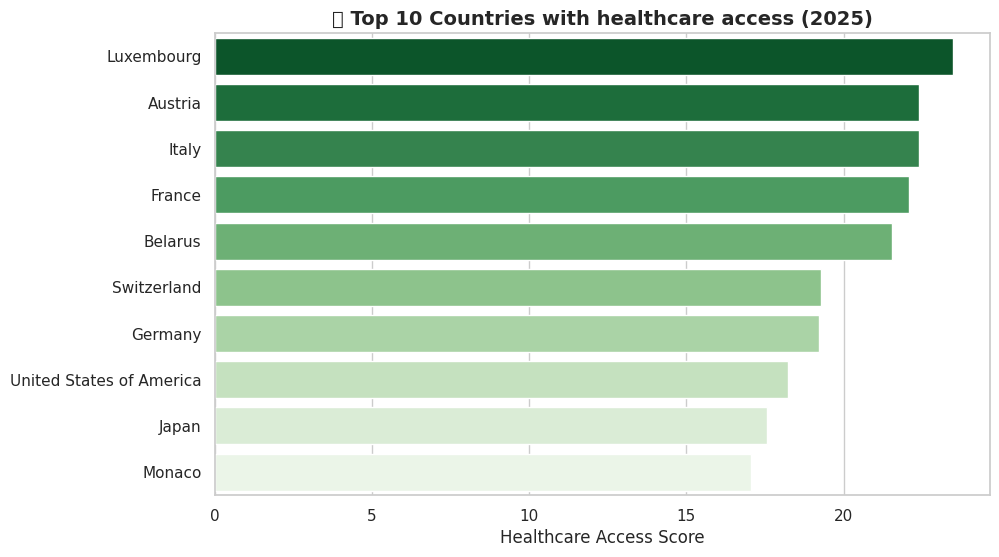

In [ ]:
df_countries_healthcare = df.groupby('WRI.Country')[['CI_05', 'CI_06']].mean().reset_index()
df_countries_healthcare["avg"] = df_countries_healthcare[['CI_05', 'CI_06']].mean(axis=1)
top_ten_countries = df_countries_healthcare.sort_values(by='avg', ascending=True).head(10).sort_values(by='avg', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_ten_countries, x='avg', y='WRI.Country', palette='Greens_r')
plt.title(f'🟢 Top 10 Countries with healthcare access (2025)', fontsize=14, fontweight='bold')
plt.xlabel('Healthcare Access Score')
plt.ylabel('')
plt.show()